# Shap and FAR synthetic data tests

In [1]:
import sys

!{sys.executable} -m pip install nbimporter

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nbimporter
import sklearn.ensemble
import xgboost as xgb
import shap

import synthetic_data as syn
import Ft_Att_Rank as far

# Load synthetic dataset

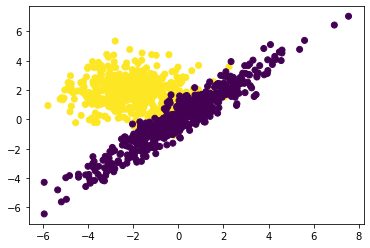

In [3]:
synth= syn.synthetic_data_generator(n=500,df=True)

X= synth.to_numpy()

plt.scatter(X[:,0],X[:,1],c=X[:,-1])

In [4]:
# split synth into features (x) and target (y)
x_syn= synth.loc[:,synth.columns[0:4]]
y_syn= synth.loc[:,synth.columns[4:5]]

#x_syn= far.normalize_selected_cols(x_syn, x_syn.columns)

In [5]:
x_syn.head()

,core_1,core_2,noise_1,noise_2
0,-1.821809,-0.302611,0.526057,-1.217679
1,-1.410102,3.516289,-3.406018,2.030946
2,-1.677580,0.401234,-3.455383,3.297440
3,-1.663423,1.825962,2.586722,-2.730967
4,-2.334104,1.690111,-0.768956,-2.613248


# ML model setup

In [6]:
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(x_syn,y_syn,train_size=0.80,
                                                                                 random_state=1234)

In [7]:
# Creates and train ML model - XGBoost random forest
xgb_model= xgb.XGBRFClassifier(learning_rate= 0.01,
                               n_estimators= 500,
                               max_depth= 6,
                               gamma= 1,
                               objective= 'binary:logistic',
                               eval_metric='logloss',
                               use_label_encoder=False)

eval_set= [(train, labels_train), (test, labels_test)] # eval_set is used for early stopping
eval_metric= ["auc","error"]

xgb_model.fit(train, labels_train, eval_metric=eval_metric, eval_set=eval_set, verbose=False)

xgb_acc= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))

xgb_acc

0.93

In [8]:
# Creates and train ML model - Random forest
rf= sklearn.ensemble.RandomForestClassifier(n_estimators=500,n_jobs=2)

rf.fit(train, labels_train.values.ravel())
rf_acc= sklearn.metrics.accuracy_score(labels_test, rf.predict(test))

rf_acc

0.935

# Shap test

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


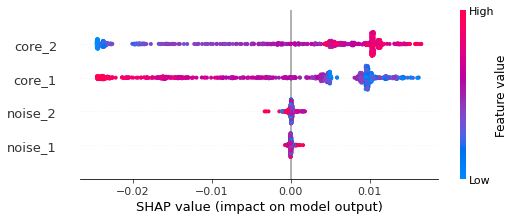

In [9]:
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values)

In [10]:
shap_values[1]

.values =
array([1.24417115e-02, 7.19642639e-03, 1.63861696e-04, 2.21584778e-05],
      dtype=float32)

.base_values =
-0.00019608783

.data =
array([-1.59981736,  0.56009267, -2.6495956 ,  2.38112329])

In [11]:
sh_vals= pd.DataFrame(shap_values[1].values, train.columns).T

sh_vals

,core_1,core_2,noise_1,noise_2
0,0.012442,0.007196,0.000164,0.000022


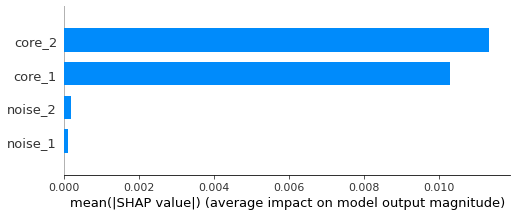

In [12]:
shap.summary_plot(shap_values, train, plot_type="bar")

In [13]:
train.head()

,core_1,core_2,noise_1,noise_2
281,-3.420881,1.123294,-1.772266,-3.502105
42,-1.599817,0.560093,-2.649596,2.381123
255,-2.003851,2.265032,3.896278,-1.641214
906,0.037382,-0.354137,-3.376042,1.911289
394,-1.408191,2.374537,2.283063,1.642703


In [14]:
labels_train.head()

,target
281,1.0
42,1.0
255,1.0
906,0.0
394,1.0


# FAR test - Global version with no retraining

In [15]:
num_fts= len(x_syn.columns)

replace_ft= far.replace_values(x_syn, x_syn.columns, num_type='mean')

acc_no_i, acc_no_ij= far.remove_and_return_costs(xgb_model, replace_ft, test, labels_test, verbose=True)

--- 0.2 seconds ---


In [16]:
acc_all_fts= xgb_acc

# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [17]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     4.971272e-01
core_1     4.922956e-01
noise_1    1.057717e-02
noise_2    1.131907e-16
dtype: float64

In [18]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.367831
noise_1    0.249366
noise_2    0.189997
core_1     0.181803
dtype: float64

In [19]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.367157
noise_1    0.249684
noise_2    0.191573
core_1     0.180405
dtype: float64

In [20]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     4.985029e-01
core_1     4.960191e-01
noise_1    5.478054e-03
noise_2    1.073360e-16
dtype: float64

# FAR test - PageRank Global version with no retraining

In [21]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# finding the stationary distribution
st_matrix1= far.p_matrix_to_row_stochastic_matrix(p_matrix1)
st_matrix2= far.p_matrix_to_row_stochastic_matrix(p_matrix2)
st_matrix3= far.p_matrix_to_row_stochastic_matrix(p_matrix3)
st_matrix4= far.p_matrix_to_row_stochastic_matrix(p_matrix4)

In [22]:
# using networkx lib

In [23]:
far.run_lib_pr(st_matrix1, x_syn.columns, iteration= 100000, damping_factor= 0.99, tolerance= 1.0e-6)

core_2     0.494568
core_1     0.490015
noise_1    0.012918
noise_2    0.002500
dtype: float64

In [24]:
far.run_lib_pr(st_matrix2, x_syn.columns, iteration= 100000, damping_factor= 0.99, tolerance= 1.0e-6)

core_2     0.353547
noise_1    0.234956
noise_2    0.231803
core_1     0.179695
dtype: float64

In [25]:
far.run_lib_pr(st_matrix3, x_syn.columns, iteration= 100000, damping_factor= 0.99, tolerance= 1.0e-6)

core_2     0.352881
noise_1    0.235178
noise_2    0.233583
core_1     0.178358
dtype: float64

In [26]:
far.run_lib_pr(st_matrix4, x_syn.columns, iteration= 100000, damping_factor= 0.99, tolerance= 1.0e-6)

core_2     0.495914
core_1     0.493691
noise_1    0.007895
noise_2    0.002500
dtype: float64

In [27]:
# using my PageRank lib

In [28]:
far.run_my_pr(st_matrix1, x_syn.columns)

core_1     0.563680
core_2     0.292766
noise_1    0.072517
noise_2    0.071037
dtype: float64

In [29]:
far.run_my_pr(st_matrix2, x_syn.columns)

core_2     0.381044
core_1     0.323201
noise_1    0.148285
noise_2    0.147470
dtype: float64

In [30]:
far.run_my_pr(st_matrix3, x_syn.columns)

core_2     0.381839
core_1     0.321383
noise_1    0.148596
noise_2    0.148182
dtype: float64

In [31]:
far.run_my_pr(st_matrix4, x_syn.columns)

core_1     0.565402
core_2     0.291998
noise_1    0.071681
noise_2    0.070919
dtype: float64

# FAR test - Local version - data and target

In [32]:
# the instance to be explained (from train dataset)
target_pos= 1

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

# FAR test - Local version with no retraining

In [33]:
num_fts= len(x_syn.columns)

replace_ft_zero= replace_ft.copy()
replace_ft_zero[x_syn.columns]= 0

acc_no_i, acc_no_ij= far.remove_and_return_costs(xgb_model, replace_ft_zero, target_inst, target_labl, verbose=True)

--- 0.06 seconds ---


In [34]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [35]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.500000
noise_2    0.142857
noise_1    0.142857
core_2     0.142857
dtype: float64

In [36]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.250000
noise_1    0.208333
noise_2    0.208333
core_2     0.208333
dtype: float64

In [37]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_2    0.25
core_1     0.25
core_2     0.25
noise_1    0.25
dtype: float64

In [38]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.4825
noise_1    0.1725
noise_2    0.1725
core_2     0.1725
dtype: float64

# FAR test - Knn-only local version

In [39]:
# neighborhood with similar elements, i.e., only instances from the same class of target instance

neigh_lb_test= labels_test[labels_test.target== target_labl.iloc[0,0]]

neigh_ft_test= test.loc[neigh_lb_test.index]

In [40]:
acc_no_i, acc_no_ij= far.knn_remove_and_return_costs(xgb_model, replace_ft, neigh_ft_test, neigh_lb_test, 
                                                     target_inst, target_labl, neighb_size= 0.3, verbose=True)

--- 0.18 seconds ---


In [41]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [42]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.453947
core_2     0.210526
noise_2    0.138158
noise_1    0.138158
dtype: float64

In [43]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_1    0.249209
noise_2    0.249209
core_2     0.235759
core_1     0.188291
dtype: float64

In [44]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_2    0.261065
noise_1    0.261065
core_2     0.258012
core_1     0.219858
dtype: float64

In [45]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.452005
core_2     0.336646
noise_2    0.105674
noise_1    0.105674
dtype: float64

# FAR test - KnnFold local version

In [46]:
acc_no_i, acc_no_ij= far.knnfold_remove_and_return_costs(xgb_model, replace_ft, neigh_ft_test, neigh_lb_test,
                                                         target_inst, target_labl, neighb_size= 0.5, k_folds=10,
                                                         verbose=True)

--- 0.93 seconds ---


In [47]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [48]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.417030
core_2     0.267032
noise_1    0.132696
noise_2    0.132696
dtype: float64

In [49]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.254896
noise_2    0.241370
noise_1    0.241370
core_1     0.188906
dtype: float64

In [50]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.272132
noise_1    0.253679
noise_2    0.253679
core_1     0.220511
dtype: float64

In [51]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.435155
core_2     0.418361
noise_1    0.073242
noise_2    0.073242
dtype: float64

# FAR test - KnnFold local version PageRank

In [52]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# converts a matrix to a row stochastic matrix
st_matrix1= far.to_row_stochastic_matrix(p_matrix1)
st_matrix2= far.to_row_stochastic_matrix(p_matrix2)
st_matrix3= far.to_row_stochastic_matrix(p_matrix3)
st_matrix4= far.to_row_stochastic_matrix(p_matrix4)

In [53]:
# using networkx lib

In [54]:
far.run_lib_pr(st_matrix1, x_syn.columns)

core_1     0.454894
core_2     0.276776
noise_1    0.134165
noise_2    0.134165
dtype: float64

In [55]:
far.run_lib_pr(st_matrix2, x_syn.columns)

noise_1    0.296673
noise_2    0.296673
core_2     0.243066
core_1     0.163587
dtype: float64

In [56]:
far.run_lib_pr(st_matrix3, x_syn.columns)

core_2     0.269870
noise_1    0.252978
noise_2    0.252978
core_1     0.224174
dtype: float64

In [57]:
far.run_lib_pr(st_matrix4, x_syn.columns)

core_1     0.407929
core_2     0.397993
noise_1    0.097039
noise_2    0.097039
dtype: float64

In [58]:
# using my PageRank lib

In [59]:
far.run_my_pr(st_matrix1, x_syn.columns)

core_1     0.582093
core_2     0.250406
noise_1    0.083750
noise_2    0.083750
dtype: float64

In [60]:
far.run_my_pr(st_matrix2, x_syn.columns)

noise_1    0.263075
noise_2    0.263075
core_2     0.251985
core_1     0.221865
dtype: float64

In [61]:
far.run_my_pr(st_matrix3, x_syn.columns)

core_1     0.346983
core_2     0.299155
noise_1    0.206335
noise_2    0.147528
dtype: float64

In [62]:
far.run_my_pr(st_matrix4, x_syn.columns)

core_1     0.520999
core_2     0.299085
noise_1    0.091791
noise_2    0.088125
dtype: float64

# FAR test - Global version with retraining

In [63]:
repeat_train= 5

acc_all_fts= far.train_model_get_acc_mean(xgb_model, train, test, labels_train, labels_test,repeat_train)

acc_no_i, acc_no_ij= far.remove_and_retrain(xgb_model, replace_ft, train, test, labels_train,
                                               labels_test,repeat_train,verbose=True)

--- 34.86 seconds ---


In [64]:
# get the probability matrix
p_matrix1= far.get_p_matrix_v1(num_fts, acc_no_i, acc_no_ij)
p_matrix2= far.get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= far.get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= far.get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= far.p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= far.p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= far.p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= far.p_matrix_to_stationary_dist(p_matrix4)

In [65]:
ft_ranking= pd.Series(stationary_d1, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.453936
core_1     0.453311
noise_1    0.064807
noise_2    0.027946
dtype: float64

In [66]:
ft_ranking= pd.Series(stationary_d2, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.285299
core_2     0.265038
noise_1    0.238735
noise_2    0.210928
dtype: float64

In [67]:
ft_ranking= pd.Series(stationary_d3, index=train.columns).sort_values(ascending=False)
ft_ranking

core_1     0.284646
core_2     0.265661
noise_1    0.237735
noise_2    0.211959
dtype: float64

In [68]:
ft_ranking= pd.Series(stationary_d4, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.475350
core_1     0.474338
noise_1    0.035271
noise_2    0.015041
dtype: float64